# Fermionic fast Fourier transform

The discrete Fourier transform on fermionic creation operators is defined as:

$$
a^\dagger_k \mapsto \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} e^{-i 2\pi k n / N} a^\dagger_n
$$

While a generic orbital rotation requires $\mathcal{O}(N^2)$ distinct rotation angle parameters via Givens decomposition, the **Fermionic Fast Fourier Transform (FFFT)** implements a [Cooley-Tukey](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm) quantum decomposition for $N = 2^k$ spatial orbitals, reducing the number of distinct gate parameters to $\mathcal{O}(\log N)$.

## Quantum circuit implementation

Under the [Jordan-Wigner transformation](https://en.wikipedia.org/wiki/Jordan%E2%80%93Wigner_transformation), `FermionicFFTSpinlessJW` and `FermionicFFTJW` construct quantum circuits for single-spin and spinful systems, respectively.

The following code cell constructs and displays a Qiskit circuit for implementing the fermionic fast Fourier transform on 4 spatial orbitals.

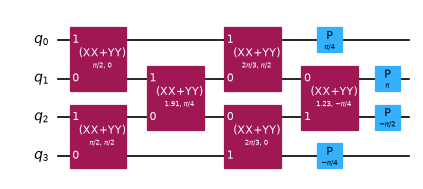

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister

import ffsim
from ffsim.qiskit.gates.fermionic_fft import FermionicFFTJW, FermionicFFTSpinlessJW

norb = 4
nelec = (2, 2)

# Spinless FFFT circuit (acts on norb qubits)
qubits = QuantumRegister(norb, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(FermionicFFTSpinlessJW(norb), qubits)

# Decompose and draw
circuit.decompose().draw("mpl", scale=0.6)

For spinful systems across $2 \times \text{norb}$ qubits, `FermionicFFTJW` applies independent sub-circuits for spin alpha (first `norb` qubits) and spin beta (last `norb` qubits).

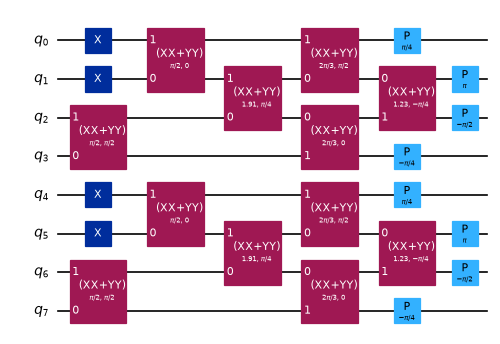

In [2]:
norb = 4
nelec = (2, 2)  # 2 alpha electrons, 2 beta electrons

qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(FermionicFFTJW(norb), qubits)

# 3. pre-initialization pass manager optimization
circuit = ffsim.qiskit.PRE_INIT.run(circuit)


circuit.decompose().draw("mpl", scale=0.6)